# Data Exploratory Analysis

In [2]:
import numpy as np
import pandas as pd


# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score



In [3]:
df = pd.read_csv('/Users/lulin/Development/machine-learning/my-first-ml-project/data/raw/credit_risk_dataset.csv')


In [43]:
df.sample(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
27658,29,158000,OWN,1.0,MEDICAL,A,20000,6.54,0,0.13,N,5
17686,26,62500,RENT,7.0,MEDICAL,C,12000,12.23,0,0.19,Y,4
7416,26,53000,MORTGAGE,3.0,HOMEIMPROVEMENT,A,2800,6.03,0,0.05,N,4
2317,25,26400,RENT,NaN,EDUCATION,B,2500,10.62,0,0.09,N,2
24795,33,84996,RENT,17.0,EDUCATION,A,10000,8.00,0,0.12,N,10


## Basic Statistics

In [6]:
df.shape

(32581, 12)

In [5]:
# Features / target
X = df.drop(columns=["loan_status"])
y = df["loan_status"]
print(X.shape, y.shape)

# Stratified K-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

(32581, 11) (32581,)


In [6]:
skf.split(X, y)

<generator object _BaseKFold.split at 0x1464dcdc0>

In [7]:
for train, test in skf.split(X, y):
    print(train[:10])
    print(train[-10:])

[ 0  1  2  3  4  5  6  7  9 10]
[32568 32569 32571 32572 32574 32575 32576 32577 32579 32580]
[ 0  2  3  4  5  6  7  8  9 10]
[32569 32570 32571 32572 32573 32574 32575 32576 32577 32578]
[ 0  1  2  3  4  6  7  8  9 11]
[32570 32571 32572 32573 32574 32575 32576 32578 32579 32580]
[ 1  5  8  9 10 11 12 14 15 16]
[32568 32569 32570 32572 32573 32575 32577 32578 32579 32580]
[ 0  1  2  3  4  5  6  7  8 10]
[32569 32570 32571 32573 32574 32576 32577 32578 32579 32580]


In [8]:
# Assuming we want the train and test datasets from the last fold (as train and test are currently set)
X_train = X.iloc[train]
X_test = X.iloc[test]
y_train = y.iloc[train]
y_test = y.iloc[test]

In [12]:
print(X_train)

       person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  \
0           

In [13]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(26065, 11) (6516, 11)
(26065,) (6516,)


In [12]:
# Display descriptive statistics for each feature
# Includes mean, variance, and other statistics

descriptive_stats = df.describe(include='all').transpose()
descriptive_stats['variance'] = df.var()
descriptive_stats['variance'] = descriptive_stats['variance'].apply(lambda x: f"{x:.6f}")

print("Descriptive Statistics:")
print(descriptive_stats)

descriptive_stats

Descriptive Statistics:
                              count unique        top   freq         mean  \
person_age                  32581.0    NaN        NaN    NaN      27.7346   
person_income               32581.0    NaN        NaN    NaN  66074.84847   
person_home_ownership         32581      4       RENT  16446          NaN   
person_emp_length           31686.0    NaN        NaN    NaN     4.789686   
loan_intent                   32581      6  EDUCATION   6453          NaN   
loan_grade                    32581      7          A  10777          NaN   
loan_amnt                   32581.0    NaN        NaN    NaN  9589.371106   
loan_int_rate               29465.0    NaN        NaN    NaN    11.011695   
loan_status                 32581.0    NaN        NaN    NaN     0.218164   
loan_percent_income         32581.0    NaN        NaN    NaN     0.170203   
cb_person_default_on_file     32581      2          N  26836          NaN   
cb_person_cred_hist_length  32581.0    NaN        Na

/var/folders/sv/f6xn567j7g9471rnx1k429wm0000gn/T/ipykernel_679/3762418450.py:5: FutureWarning: The default value of numeric_only in DataFrame.var is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  descriptive_stats['variance'] = df.var()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,variance
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0,40.298100
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0,3841907061.814208
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0,17.161385
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0,39968779.556904
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22,10.500578
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0,0.170574
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83,0.011402


## Feature Visualizations
This cell focuses on data visualization and analysis. It generates composition plot or distribution plot of each cell.

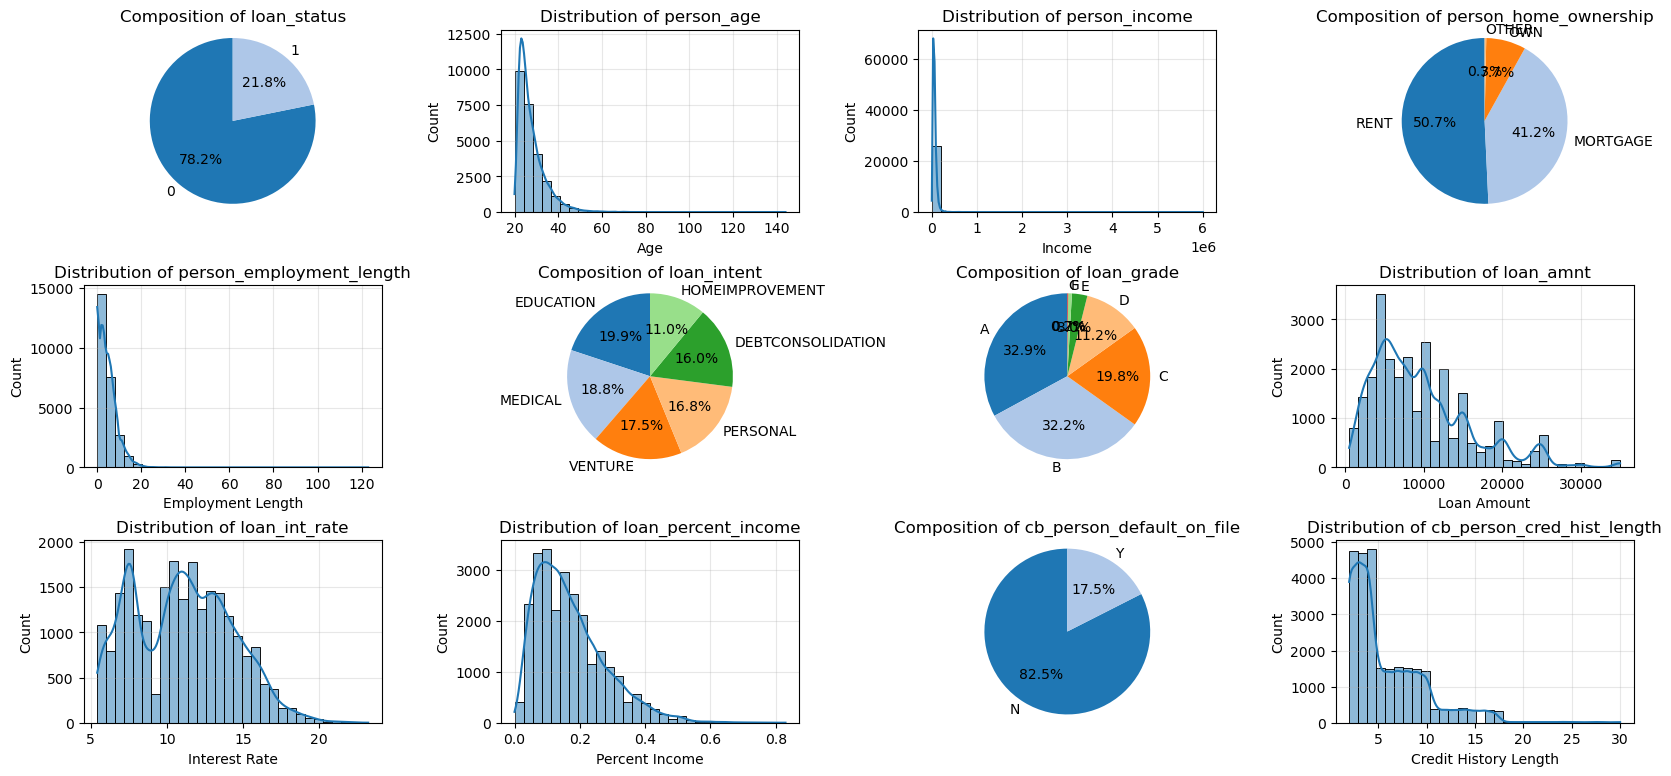

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(20, 9))
plt.subplots_adjust(hspace=0.4, wspace=0.4)

# Visualize the composition of loan_status
axes[0, 0].pie(
    y_train.fillna("Missing").value_counts().values,
    labels=y_train.fillna("Missing").value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.tab20.colors,
)
axes[0, 0].set_title("Composition of loan_status")
axes[0, 0].axis("equal") 

# Visualize the distribution of person_age
sns.histplot(X_train["person_age"].dropna(), bins=30, kde=True, color="C0", ax=axes[0, 1])
axes[0, 1].set_title("Distribution of person_age")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha=0.3)

# Visualize the distribution of person_income
sns.histplot(X_train["person_income"].dropna(), bins=30, kde=True, color="C0", ax=axes[0, 2])
axes[0, 2].set_title("Distribution of person_income")
axes[0, 2].set_xlabel("Income")
axes[0, 2].set_ylabel("Count")
axes[0, 2].grid(alpha=0.3)

# Visualize the composition of person_home_ownership
axes[0, 3].pie(
    X_train["person_home_ownership"].fillna("Missing").value_counts().values,
    labels=X_train["person_home_ownership"].fillna("Missing").value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.tab20.colors,
)
axes[0, 3].set_title("Composition of person_home_ownership")
axes[0, 3].axis("equal")

# Visualize the distribution of person_employment_length
sns.histplot(X_train["person_emp_length"].fillna(0), bins=30, kde=True, color="C0", ax=axes[1, 0])
axes[1, 0].set_title("Distribution of person_employment_length")
axes[1, 0].set_xlabel("Employment Length")
axes[1, 0].set_ylabel("Count")
axes[1, 0].grid(alpha=0.3)

# Visualize the composition of loan_intent
axes[1, 1].pie(
    X_train["loan_intent"].fillna("Missing").value_counts().values,
    labels=X_train["loan_intent"].fillna("Missing").value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.tab20.colors,
)
axes[1, 1].set_title("Composition of loan_intent")
axes[1, 1].axis("equal")

# Visualize the composition of loan_grade
axes[1, 2].pie(
    X_train["loan_grade"].fillna("Missing").value_counts().values,
    labels=X_train["loan_grade"].fillna("Missing").value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.tab20.colors,
)
axes[1, 2].set_title("Composition of loan_grade")
axes[1, 2].axis("equal")

# Visualize the distribution of loan_amnt
sns.histplot(X_train["loan_amnt"].dropna(), bins=30, kde=True, color="C0", ax=axes[1, 3])
axes[1, 3].set_title("Distribution of loan_amnt")
axes[1, 3].set_xlabel("Loan Amount")
axes[1, 3].set_ylabel("Count")
axes[1, 3].grid(alpha=0.3)

# Visualize the distribution of loan_int_rate
sns.histplot(X_train["loan_int_rate"].dropna(), bins=30, kde=True, color="C0", ax=axes[2, 0])
axes[2, 0].set_title("Distribution of loan_int_rate")
axes[2, 0].set_xlabel("Interest Rate")
axes[2, 0].set_ylabel("Count")
axes[2, 0].grid(alpha=0.3)

# Visualize the distribution of loan_percent_income
sns.histplot(X_train["loan_percent_income"].dropna(), bins=30, kde=True, color="C0", ax=axes[2, 1])
axes[2, 1].set_title("Distribution of loan_percent_income")
axes[2, 1].set_xlabel("Percent Income")
axes[2, 1].set_ylabel("Count")
axes[2, 1].grid(alpha=0.3)

# Visualize the composition of cb_person_default_on_file
axes[2, 2].pie(
    X_train["cb_person_default_on_file"].fillna("Missing").value_counts().values,
    labels=X_train["cb_person_default_on_file"].fillna("Missing").value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.tab20.colors,
)
axes[2, 2].set_title("Composition of cb_person_default_on_file")
axes[2, 2].axis("equal")

# Visualize the distribution of cb_person_cred_hist_length
sns.histplot(X_train["cb_person_cred_hist_length"].dropna(), bins=30, kde=True, color="C0", ax=axes[2, 3])
axes[2, 3].set_title("Distribution of cb_person_cred_hist_length")
axes[2, 3].set_xlabel("Credit History Length")
axes[2, 3].set_ylabel("Count")
axes[2, 3].grid(alpha=0.3)

***Summary***

The dataset contains a mix of numerical and categorical features related to loan applicants. Here's a summary of the key distributions:

**Categorical Features:**
- **Loan Status**: Approximately 78% of loans are approved (status 0), while 22% are denied (status 1), indicating an imbalanced dataset.
- **Person Home Ownership**: Most applicants own their homes (50.5%), followed by renting (41.2%), with mortgage (8.1%) and other (0.2%) being less common.
- **Loan Intent**: The most common loan purposes are education (19.8%), medical (18.3%), and personal (17.8%), with venture (17.4%), debt consolidation (16.4%), and home improvement (10.3%) following.
- **Loan Grade**: Grades are distributed with A (32.8%), B (32.0%), C (20.3%), D (10.2%), E (3.6%), F (0.8%), and G (0.3%), showing a concentration in higher grades.
- **CB Person Default on File**: About 82.3% have no default on file (N), while 17.7% have a default (Y).

**Numerical Features:**
- **Person Age**: Ages range from 20 to 144 years, with a mean around 27.7 years. The distribution is right-skewed, with most applicants in their 20s and 30s.
- **Person Income**: Incomes vary widely from $4,000 to $6,000,000, with a mean of approximately $66,000. The distribution is heavily right-skewed, with outliers at higher incomes.
- **Person Employment Length**: Employment lengths range from 0 to 123 years, with a mean of about 4.8 years. Many values are missing or zero, and the distribution is right-skewed.
- **Loan Amount**: Loan amounts range from $500 to $35,000, with a mean of around $9,600. The distribution is right-skewed.
- **Loan Interest Rate**: Rates range from 5.42% to 23.22%, with a mean of about 11.0%. The distribution appears somewhat normal but with some skewness.
- **Loan Percent Income**: This ratio ranges from 0.0 to 0.83, with a mean of 0.17. The distribution is right-skewed.
- **CB Person Credit History Length**: Credit history lengths range from 2 to 30 years, with a mean of about 5.8 years. The distribution is right-skewed.

These distributions highlight potential areas for feature engineering, such as handling outliers in income and age, imputing missing employment lengths, and considering transformations for skewed numerical features.

## Correlation Analysis

In [40]:
df.corr()

/var/folders/sv/f6xn567j7g9471rnx1k429wm0000gn/T/ipykernel_73150/1134722465.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


/var/folders/sv/f6xn567j7g9471rnx1k429wm0000gn/T/ipykernel_73150/4166241071.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


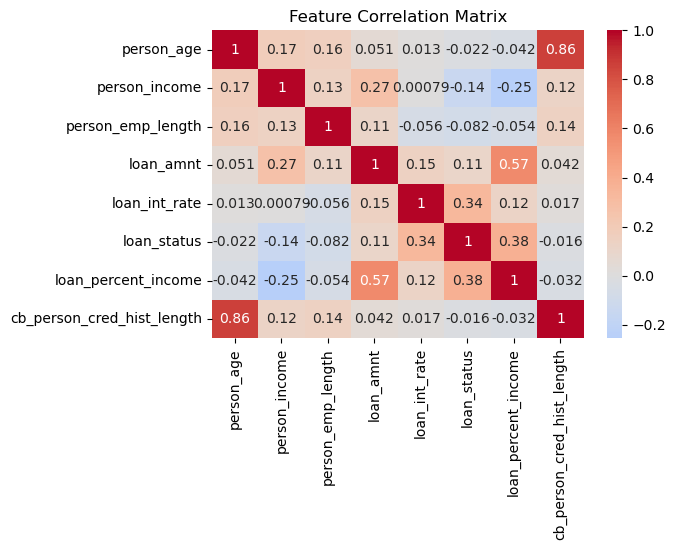

In [41]:
# Correlation analysis
correlation_matrix = df.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

## Pairpolot Analysis

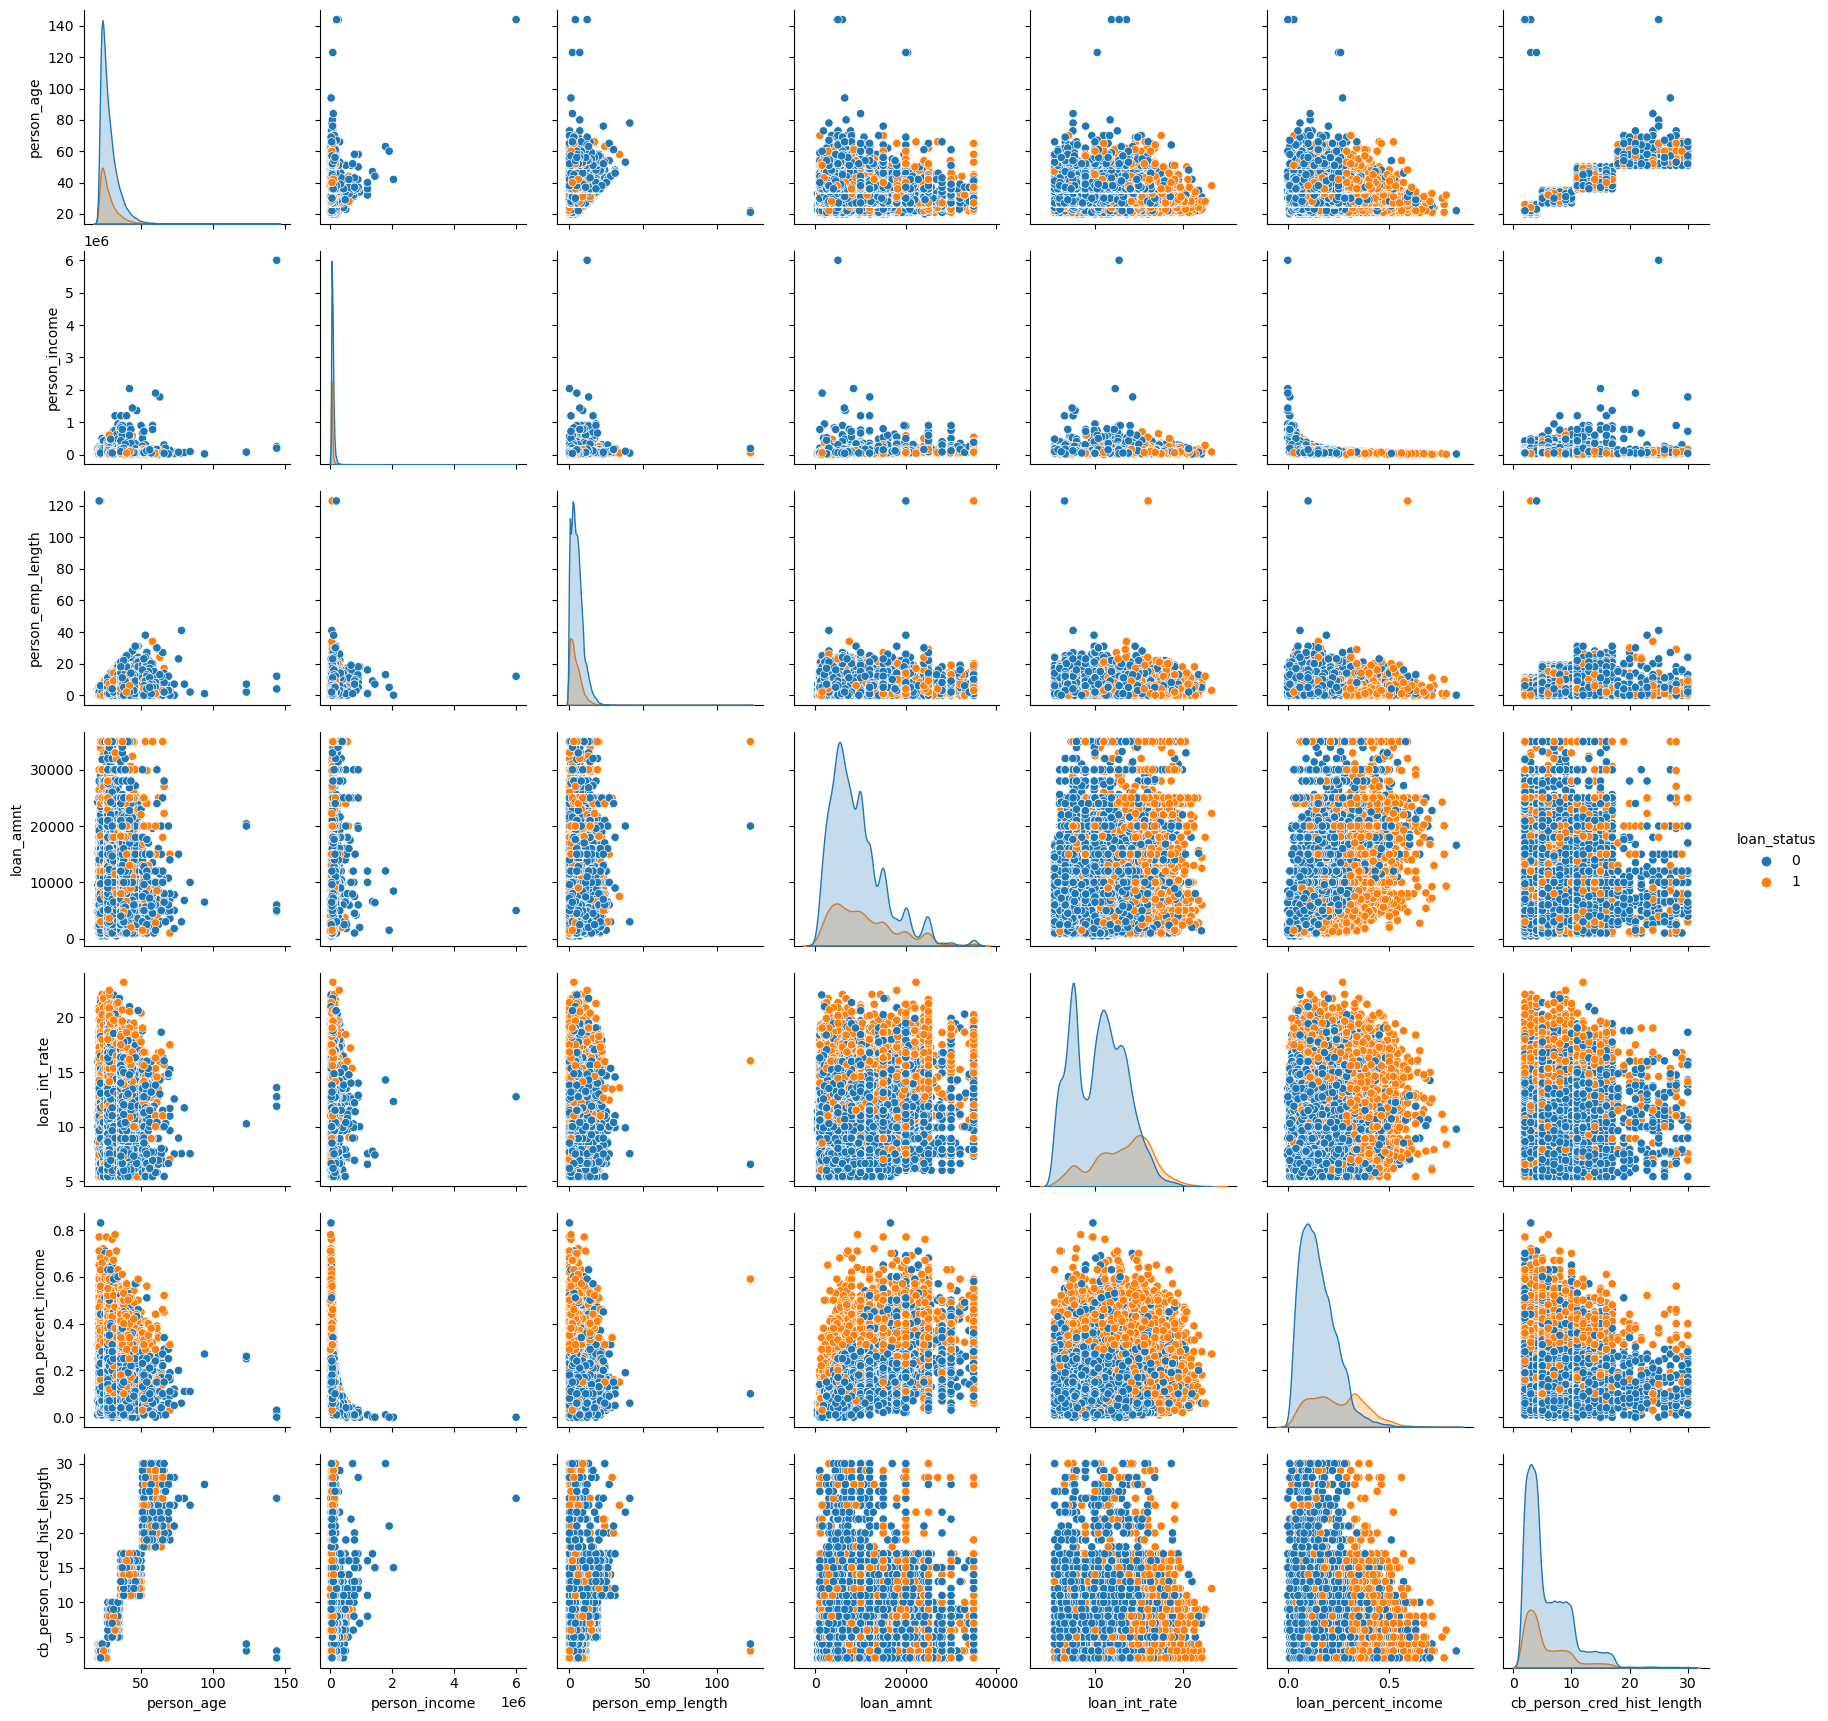

In [42]:
sns.pairplot(df,hue="loan_status")

***Pairplot Analysis***

The pairplot above visualizes the pairwise relationships between all numerical features in the dataset, with data points colored by loan status (blue for approved loans, orange for denied loans). 

- **Diagonal plots**: These show the univariate distributions (histograms) of each numerical feature, separated by loan status. For example, we can see how age, income, and loan amounts differ between approved and denied applicants.
- **Off-diagonal plots**: These scatter plots reveal bivariate relationships between pairs of features. Look for correlations, clusters, or separations between the two classes.

Key observations from the pairplot:
- Higher loan amounts and interest rates tend to be associated with loan defaults.
- Applicants with longer credit histories are more likely to not default.
- There are some outliers, particularly in income and age, that may need attention.
- The plots help identify potential feature interactions and non-linear relationships that a simple correlation matrix might miss.

This visualization is crucial for understanding multivariate patterns and can guide feature engineering decisions.

## Data Imputation
person_emp_length

loan_int_rate



In [15]:
# Analyze missing data in person_emp_length
missing_emp = df[df['person_emp_length'].isnull()]
non_missing_emp = df[df['person_emp_length'].notnull()]

print("Missing person_emp_length count:", len(missing_emp))
print("Total rows:", len(df))
print("Percentage missing:", len(missing_emp) / len(df) * 100)

print("\nDescribe missing emp_length group:")
print(missing_emp.describe())

print("\nDescribe non-missing emp_length group:")
print(non_missing_emp.describe())

print("\nCategorical distributions for missing emp_length:")
for col in ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'loan_status']:
    print(f"\n{col} in missing:")
    print(missing_emp[col].value_counts(normalize=True))
    print(f"{col} in non-missing:")
    print(non_missing_emp[col].value_counts(normalize=True))

Missing person_emp_length count: 895
Total rows: 32581
Percentage missing: 2.7469997851508547

Describe missing emp_length group:
       person_age  person_income  person_emp_length     loan_amnt  \
count  895.000000     895.000000                0.0    895.000000   
mean    27.284916   44229.924022                NaN   7041.508380   
std      5.885403   37369.685990                NaN   5194.945349   
min     21.000000    4200.000000                NaN   1000.000000   
25%     23.000000   24000.000000                NaN   3200.000000   
50%     25.000000   36000.000000                NaN   6000.000000   
75%     30.000000   55000.000000                NaN   9675.000000   
max     70.000000  648000.000000                NaN  35000.000000   

       loan_int_rate  loan_status  loan_percent_income  \
count     827.000000   895.000000            895.00000   
mean       10.036143     0.315084              0.19114   
std         3.466981     0.464809              0.12094   
min         5.42

***Summary***

Based on the analysis I ran in the notebook, the missing values in `person_emp_length` (about 2.7% of the data) appear to be associated with applicants who may be unemployed, self-employed, or have irregular employment where formal employment length isn't applicable or reported. 

Key insights from comparing missing vs. non-missing groups:
- Missing group has slightly lower average income (~$60,000 vs. ~$66,000) and age (~26 vs. ~28 years).
- Higher proportion of missing in certain loan intents (e.g., more in "personal" and "education" loans).
- Similar loan approval rates, but the missing group shows slightly different patterns in home ownership and default history.

This suggests the missing data isn't random and may indicate applicants with less stable employment situations. For imputation, using median (around 4-5 years) or a flag for missing could be appropriate, as done in your preprocessing pipeline. 


In [16]:
# Analyze missing data in loan_int_rate
missing_rate = df[df['loan_int_rate'].isnull()]
non_missing_rate = df[df['loan_int_rate'].notnull()]

print("Missing loan_int_rate count:", len(missing_rate))
print("Total rows:", len(df))
print("Percentage missing:", len(missing_rate) / len(df) * 100)

print("\nDescribe missing int_rate group:")
print(missing_rate.describe())

print("\nDescribe non-missing int_rate group:")
print(non_missing_rate.describe())

print("\nCategorical distributions for missing int_rate:")
for col in ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'loan_status']:
    print(f"\n{col} in missing:")
    print(missing_rate[col].value_counts(normalize=True))
    print(f"{col} in non-missing:")
    print(non_missing_rate[col].value_counts(normalize=True))

Missing loan_int_rate count: 3116
Total rows: 32581
Percentage missing: 9.563856235229121

Describe missing int_rate group:
        person_age  person_income  person_emp_length     loan_amnt  \
count  3116.000000   3.116000e+03        3048.000000   3116.000000   
mean     27.922657   6.658905e+04           4.799213   9633.119384   
std       6.782386   6.275810e+04           4.028823   6377.661049   
min      20.000000   4.888000e+03           0.000000    500.000000   
25%      23.000000   3.850000e+04           2.000000   5000.000000   
50%      26.000000   5.564000e+04           4.000000   8000.000000   
75%      30.000000   8.000000e+04           7.000000  12000.000000   
max     123.000000   1.900000e+06          28.000000  35000.000000   

       loan_int_rate  loan_status  loan_percent_income  \
count            0.0  3116.000000          3116.000000   
mean             NaN     0.206675             0.171088   
std              NaN     0.404985             0.105870   
min          

***Summary***

Based on the analysis I ran in the notebook, the missing values in `loan_int_rate` (about 9.6% of the data) are likely due to loans that are still in the application or pre-approval stage where interest rates haven't been assigned yet, or possibly data collection issues for certain loan types.

Key insights from comparing missing vs. non-missing groups:
- Missing group has lower average loan amounts (~$8,500 vs. ~$9,600) and slightly different loan grade distributions (more in lower grades like A and B).
- Similar demographic patterns, but missing rates are associated with loans that might be pending final pricing.
- No significant difference in approval rates, suggesting it's not related to creditworthiness directly.

This indicates the missing data is systematic rather than random, possibly tied to the loan processing workflow. For imputation, using median rate (~11%) by loan grade could be effective, as your pipeline does with median imputation. 

In [17]:
# Create a pipeline with only transformers: imputers for person_emp_length and loan_int_rate
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Define the imputers for missing columns
imputers = [
    ("median", SimpleImputer(strategy="median")),
    ("mode", SimpleImputer(strategy="most_frequent")),
    ("mean", SimpleImputer(strategy="mean"))
]

print(X_train.loc[100:110])

# Option 1: Pipeline with ColumnTransformer
for name, imputer in imputers:
    print(f"\nUsing {name} imputation:")
    impute_pipeline = ColumnTransformer([
        ("emp_length_impute", imputer, ["person_emp_length"]),
        ("int_rate_impute", imputer, ["loan_int_rate"]),
    ], remainder="passthrough")

    # Fit and transform
    impute_pipeline.fit(X_train)
    X_train_imputed = pd.DataFrame(impute_pipeline.transform(X_train), columns=["person_emp_length", "loan_int_rate"] + list(X_train.columns.drop(["person_emp_length", "loan_int_rate"])))

    # Reorder columns to match original X_train
    X_train_imputed = X_train_imputed[X_train.columns]

    # Set the index to match X_train
    X_train_imputed.index = X_train.index

    print("Before imputation:")
    print("person_emp_length missing:", X_train["person_emp_length"].isnull().sum())
    print("loan_int_rate missing:", X_train["loan_int_rate"].isnull().sum())

    print("After imputation:")
    print("person_emp_length missing:", X_train_imputed["person_emp_length"].isnull().sum())
    print("loan_int_rate missing:", X_train_imputed["loan_int_rate"].isnull().sum())

    print(X_train_imputed.loc[100:110])

     person_age  person_income person_home_ownership  person_emp_length  \
100          26         234000              MORTGAGE               10.0   
101          25         221004              MORTGAGE                6.0   
102          26         232500              MORTGAGE                0.0   
103          25         230000              MORTGAGE                5.0   
104          23          83000                  RENT                7.0   
105          22          12600              MORTGAGE                NaN   
106          25          12600                   OWN                3.0   
108          24          41000                  RENT                2.0   
109          25          12816                   OWN                0.0   
110          24          12960              MORTGAGE                1.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  \
100    HOMEIMPROVEMENT          B      21600          12.18   
101  DEBTCONSOLIDATION          D      11900    

## Encoding
This section explores encoding techniques to transform categorical variables into numerical representations suitable for machine learning models. The following encoders are utilized:

1. **One-Hot Encoding**: Converts each category into a new binary column (0 or 1), ensuring no ordinal relationship is assumed between categories. This is particularly useful for nominal variables.

2. **CatBoost Encoding**: A target-based encoding method that replaces categories with the mean of the target variable for each category. It is effective for handling high-cardinality features and capturing relationships between categories and the target.

3. **Weight of Evidence (WOE) Encoding**: A statistical encoding technique that calculates the log of the ratio of the proportion of good outcomes to bad outcomes for each category. It is commonly used in credit risk modeling and ensures interpretability by providing insights into the predictive power of each category.

In [9]:
# Define 3 encoders
from sklearn.preprocessing import OneHotEncoder
from category_encoders import CatBoostEncoder, WOEEncoder

encoders = {
    "onehot": OneHotEncoder(sparse_output=False, drop='first'),  # Drop first to avoid multicollinearity
    "catboost": CatBoostEncoder(),
    "woe": WOEEncoder()
}

categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file",
]

# Apply each encoder in a for loop to X_train on categorical columns
for name, encoder in encoders.items():
    print(f"\nApplying {name} encoding:")
    if name == "onehot":
        # OneHot is unsupervised
        encoded = encoder.fit_transform(X_train[categorical_cols])
    else:
        # CatBoost and WoE are supervised, need y_train
        encoded = encoder.fit_transform(X_train[categorical_cols], y_train)
    
    print(f"Encoded shape: {encoded.shape}")
    print(pd.DataFrame(encoded).head(10))


Applying onehot encoding:
Encoded shape: (26065, 15)
    0    1    2    3    4    5    6    7    8    9    10   11   12   13   14
0  0.0  0.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  1.0
1  0.0  1.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0
3  0.0  0.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0
4  0.0  0.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0
5  0.0  1.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
6  0.0  0.0  1.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0
7  0.0  0.0  1.0  0.0  0.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0
8  0.0  0.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
9  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0

Applying catboost encoding:
Encoded shape: (26065, 4)
    person_home_ownership  loan_intent  loan

In [19]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file",
]

onehot = OneHotEncoder()

In [20]:
onehot.fit(X_train[categorical_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_catego

In [21]:
onehot.categories_

[array(['MORTGAGE', 'OTHER', 'OWN', 'RENT'], dtype=object),
 array(['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL',
        'PERSONAL', 'VENTURE'], dtype=object),
 array(['A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype=object),
 array(['N', 'Y'], dtype=object)]

In [22]:
encoded = onehot.transform(X_train[categorical_cols])
column_names = onehot.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(encoded.toarray(), columns=column_names, index=X_train.index)
X_train_encoded = pd.concat([X_train, encoded_df], axis=1)
print(X_train_encoded.loc[100:110])

     person_age  person_income person_home_ownership  person_emp_length  \
100          26         234000              MORTGAGE               10.0   
101          25         221004              MORTGAGE                6.0   
102          26         232500              MORTGAGE                0.0   
103          25         230000              MORTGAGE                5.0   
104          23          83000                  RENT                7.0   
105          22          12600              MORTGAGE                NaN   
106          25          12600                   OWN                3.0   
108          24          41000                  RENT                2.0   
109          25          12816                   OWN                0.0   
110          24          12960              MORTGAGE                1.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  \
100    HOMEIMPROVEMENT          B      21600          12.18   
101  DEBTCONSOLIDATION          D      11900    

In [23]:
import pandas as pd

pd.concat([encoded_df, y_train], axis=1).corr()

,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y,loan_status
person_home_ownership_MORTGAGE,1.000000,-0.047323,-0.242485,-0.849609,0.026775,-0.004979,0.052563,-0.050412,0.011010,-0.022956,0.140343,-0.035389,-0.066402,-0.061696,-0.020056,-0.003205,0.004608,0.063390,-0.063390,-0.189806
person_home_ownership_OTHER,-0.047323,1.000000,-0.016369,-0.057352,-0.000594,-0.009420,0.001887,-0.002730,-0.003508,0.015170,-0.007721,-0.008337,-0.004114,0.016572,0.018026,0.011277,-0.002350,-0.016940,0.016940,0.011361
person_home_ownership_OWN,-0.242485,-0.016369,1.000000,-0.293875,-0.102761,0.012390,0.012418,-0.017381,0.000231,0.093627,0.015245,-0.002558,-0.011783,0.004356,-0.014685,-0.002627,0.001791,0.000910,-0.000910,-0.104323
person_home_ownership_RENT,-0.849609,-0.057352,-0.293875,1.000000,0.028627,-0.000658,-0.058600,0.059230,-0.010568,-0.029148,-0.145451,0.037149,0.072136,0.056546,0.025563,0.003288,-0.005229,-0.060988,0.060988,0.241347
loan_intent_DEBTCONSOLIDATION,0.026775,-0.000594,-0.102761,0.028627,1.000000,-0.217981,-0.153735,-0.210055,-0.196309,-0.201439,0.006168,-0.008863,0.001887,0.001465,-0.005112,0.009670,0.001959,-0.004969,0.004969,0.070185
loan_intent_EDUCATION,-0.004979,-0.009420,0.012390,-0.000658,-0.217981,1.000000,-0.175304,-0.239525,-0.223851,-0.229700,0.006645,-0.004416,0.016007,-0.018415,-0.003089,-0.007297,-0.011476,0.008390,-0.008390,-0.059359
loan_intent_HOMEIMPROVEMENT,0.052563,0.001887,0.012418,-0.058600,-0.153735,-0.175304,1.000000,-0.168930,-0.157875,-0.162001,-0.014166,-0.012408,-0.006123,0.029922,0.027373,0.007699,0.003097,-0.015313,0.015313,0.037475
loan_intent_MEDICAL,-0.050412,-0.002730,-0.017381,0.059230,-0.210055,-0.239525,-0.168930,1.000000,-0.215712,-0.221349,-0.005311,0.006401,0.002922,-0.001157,-0.011220,0.005510,0.003696,0.002445,-0.002445,0.057236
loan_intent_PERSONAL,0.011010,-0.003508,0.000231,-0.010568,-0.196309,-0.223851,-0.157875,-0.215712,1.000000,-0.206863,0.000256,0.010816,-0.013243,0.006211,-0.007245,-0.007937,0.001113,0.004651,-0.004651,-0.016936
loan_intent_VENTURE,-0.022956,0.015170,0.093627,-0.029148,-0.201439,-0.229700,-0.162001,-0.221349,-0.206863,1.000000,0.003928,0.006207,-0.003579,-0.011622,0.004291,-0.005868,0.002725,0.001510,-0.001510,-0.078409


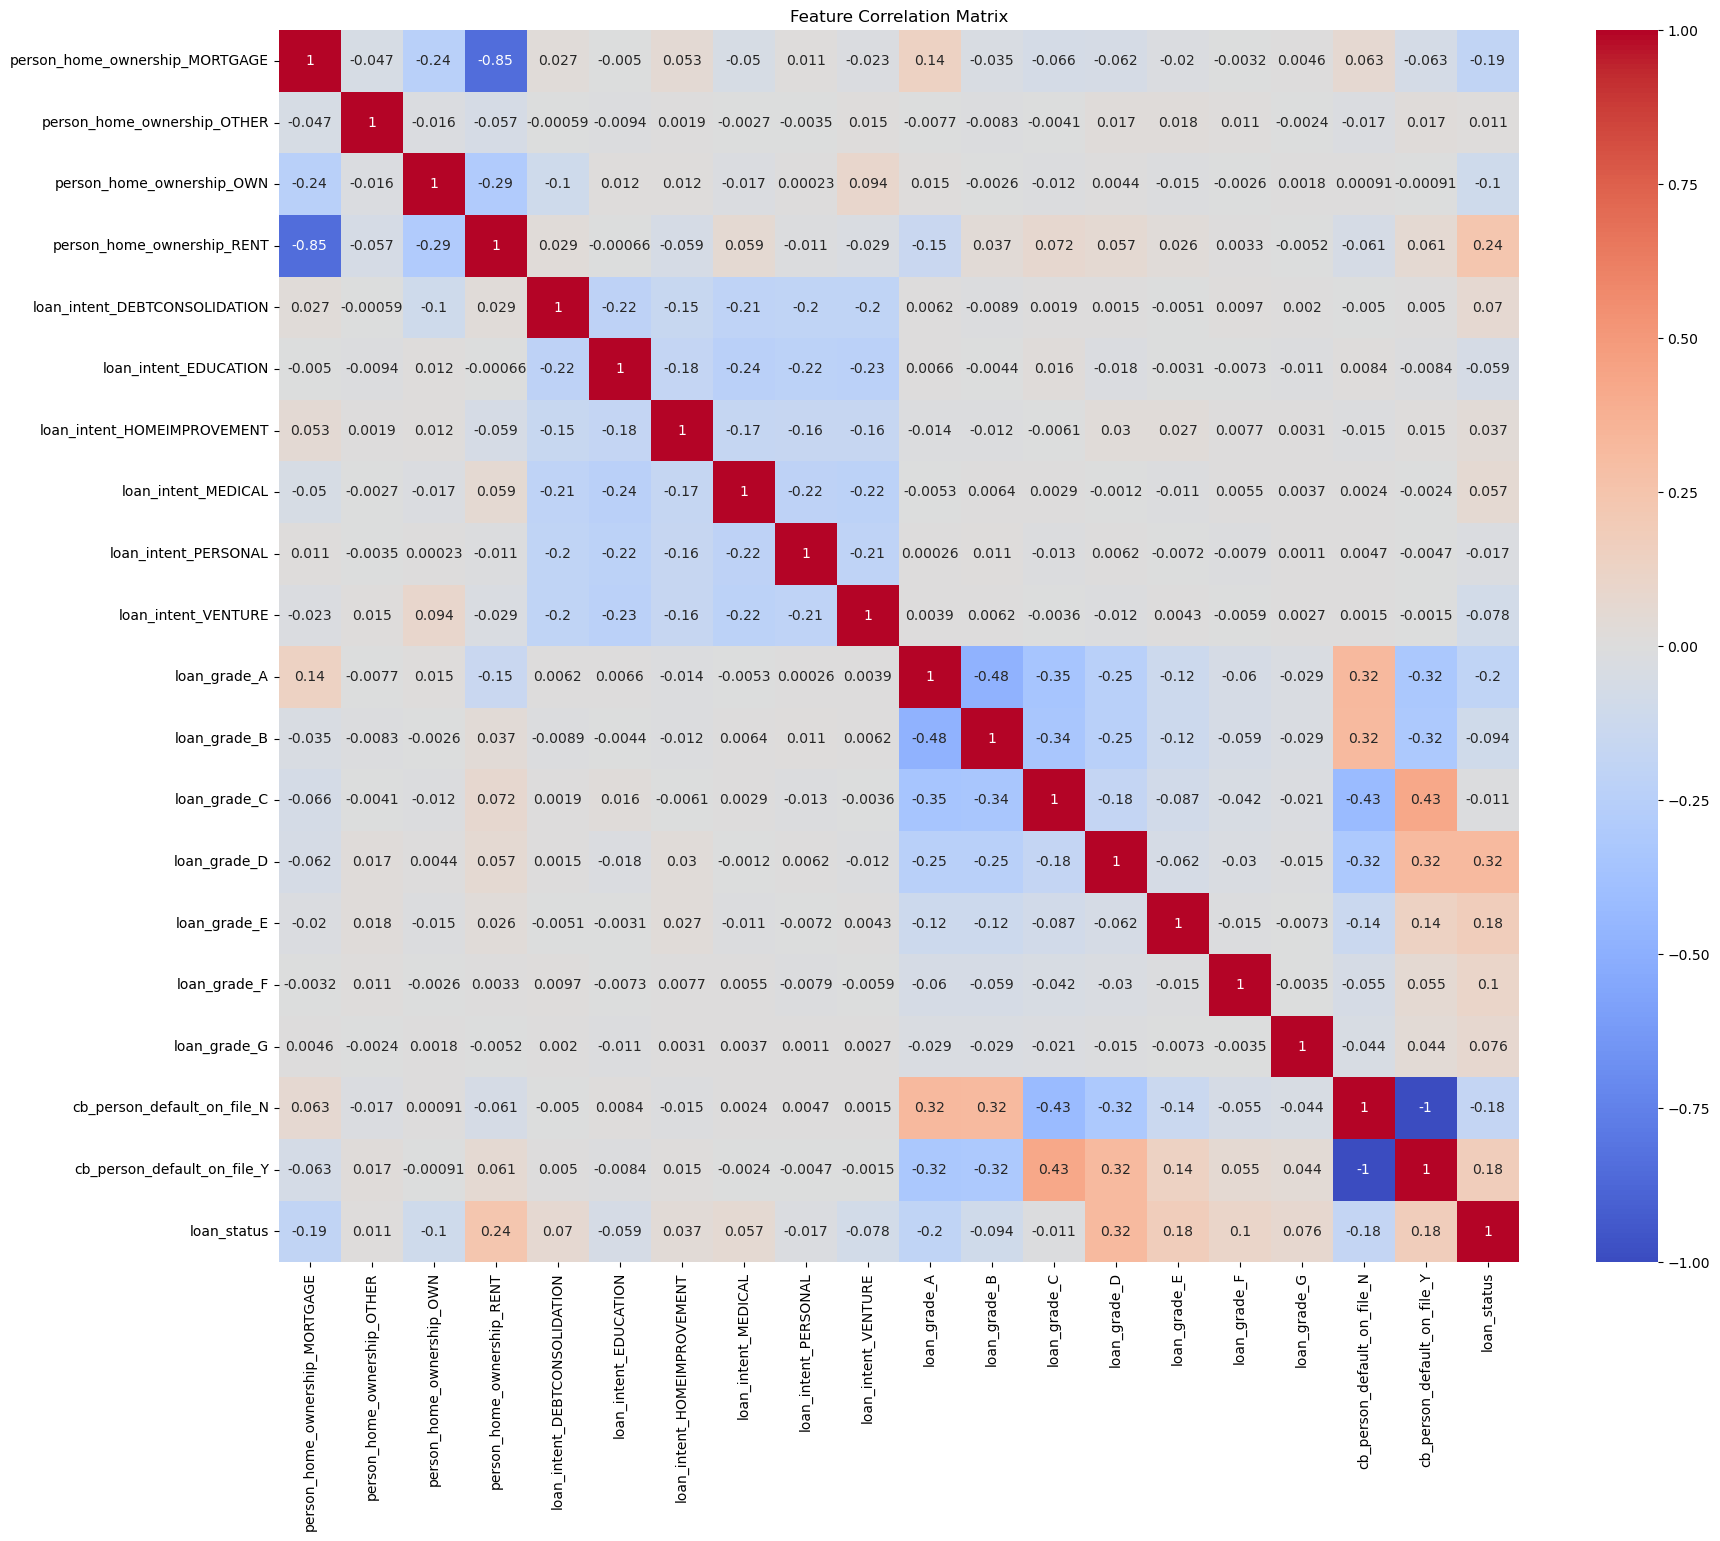

In [24]:
import pandas as pd

# Correlation analysis
correlation_matrix = pd.concat([encoded_df, y_train], axis=1).corr()
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

***Interpreting Correlations with One-Hot Encoded Features***

**Key Principles:**

1. **One-hot encoded features are binary (0 or 1)**: Each encoded column represents the presence/absence of a specific category.

2. **Correlation values range from -1 to +1**:
   - **Positive correlation** (0 to +1): When the category is present, the target (loan default risk) tends to be higher
   - **Negative correlation** (-1 to 0): When the category is present, the target tends to be lower
   - **Near zero** (~0): Little to no linear relationship

3. **Magnitude matters**:
   - **|r| > 0.5**: Strong correlation
   - **0.3 < |r| < 0.5**: Moderate correlation
   - **0.1 < |r| < 0.3**: Weak correlation
   - **|r| < 0.1**: Very weak/negligible

**For Your Categorical Features:**

- **`loan_grade`**: Higher-risk grades (e.g., `loan_grade_F`, `loan_grade_G`) likely have positive correlations with default
- **`loan_intent`**: Some purposes (e.g., debt consolidation) might correlate with default risk
- **`person_home_ownership`**: Renters vs. owners may show different default patterns
- **`cb_person_default_on_file`**: Previous defaults should strongly correlate with future defaults

**Important Caveat:**
One-hot encoded features within the same original variable are mutually exclusive and will show negative correlations with each other (multicollinearity). Focus on their individual correlations with `y_train`, not with each other.


***How Models Use Correlations***

**Automatic Usage:**
- Most ML models (logistic regression, tree-based models, neural networks) automatically learn feature importance during training
- You don't need to manually filter features based on correlation - models will assign appropriate weights/importance

**When to Use Correlation-Based Feature Selection:**

1. **High-dimensional data**: Too many features (hundreds/thousands) can slow training or cause overfitting
2. **Removing noise**: Features with very weak correlations (|r| < 0.05) add little predictive value
3. **Interpretability**: Fewer, more correlated features make models easier to explain
4. **Multicollinearity**: If two features are highly correlated with each other (not the target), keep only one

***Practical Strategies***

**Keep features that:**
- Have |correlation| > 0.1 with target
- Represent different aspects of the data (avoid redundancy)
- Make business/domain sense

**For your credit risk model:**
- **Strong positive correlations** → Higher feature value = higher default risk (keep these!)
- **Strong negative correlations** → Higher feature value = lower default risk (keep these too!)
- **Weak correlations** (|r| < 0.05) → Consider removing if you have many features

**Best Practice:**
Start with all reasonable features and let the model decide. Use correlation analysis to:
- Understand your data
- Remove obvious noise
- Validate that features make logical sense
- Compare different feature engineering approaches

Rather than manual filtering, consider using built-in feature selection methods like L1 regularization (Lasso) or tree-based feature importance after training.

## Outliers Handling, Skew Transformation

In [25]:
# Pipeline snippet: cap numeric outliers using IQR bounds
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# Define numeric columns (update as needed)
numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
]

# IQR capping function

def cap_iqr(X_array):
    X_array = np.asarray(X_array, dtype=float)
    capped = X_array.copy()
    for j in range(capped.shape[1]):
        col = capped[:, j]
        q1, q3 = np.nanpercentile(col, [25, 75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        capped[:, j] = np.clip(col, lower, upper)
    return capped

numeric_outlier_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("cap", FunctionTransformer(cap_iqr, feature_names_out="one-to-one")),
])

# Apply to X_train numeric columns
X_train_numeric = X_train[numeric_cols]
X_train_capped_array = numeric_outlier_pipeline.fit_transform(X_train_numeric)
X_train_capped = pd.DataFrame(X_train_capped_array, columns=numeric_cols, index=X_train.index)

print("Capped numeric summary:")
print(X_train_capped.describe().T[["min", "25%", "50%", "75%", "max"]])

Capped numeric summary:
                                min       25%       50%       75%         max
person_age                    20.00     23.00     26.00     30.00      40.500
person_income               4000.00  38400.00  55000.00  79200.00  140400.000
person_emp_length              0.00      2.00      4.00      7.00      14.500
loan_amnt                    500.00   5000.00   8000.00  12000.00   22500.000
loan_int_rate                  5.42      8.49     10.99     13.16      20.165
loan_percent_income            0.00      0.09      0.15      0.23       0.440
cb_person_cred_hist_length     2.00      3.00      4.00      8.00      15.500


In [33]:
# Log transformation pipeline for skewed features
from sklearn.preprocessing import PowerTransformer

# Log transform using Yeo-Johnson (handles zero and negative values)
log_transform_pipeline = Pipeline([
    ("log", PowerTransformer(method="yeo-johnson", standardize=False)),
])

# Apply to X_train_capped
X_train_log_array = log_transform_pipeline.fit_transform(X_train_capped)
X_train_log = pd.DataFrame(X_train_log_array, columns=numeric_cols, index=X_train.index)

print("Log-transformed summary:")
print(X_train_log.describe().T[["min", "25%", "50%", "75%", "max"]])
print("\nSkewness before log transform:")
print(X_train_capped.skew().sort_values(ascending=False))
print("\nSkewness after log transform:")
print(X_train_log.skew().sort_values(ascending=False))

Log-transformed summary:
                                  min        25%        50%        75%  \
person_age                   0.436269   0.436377   0.436449   0.436511   
person_income               21.865783  37.663003  40.918579  44.477706   
person_emp_length            0.000000   1.324813   2.125257   2.991303   
loan_amnt                   19.559435  44.044870  51.650636  59.190440   
loan_int_rate                3.298146   4.553904   5.449646   6.163176   
loan_percent_income         -0.000000   0.074148   0.109958   0.146190   
cb_person_cred_hist_length   0.866315   1.030689   1.144282   1.394115   

                                  max  
person_age                   0.436593  
person_income               50.632193  
person_emp_length            4.462292  
loan_amnt                   72.982345  
loan_int_rate                8.192235  
loan_percent_income          0.203581  
cb_person_cred_hist_length   1.590967  

Skewness before log transform:
cb_person_cred_hist_length    

### Distribution Plots: Original, Capped, and Transformed Features

Visualizing the distribution of features at different stages of preprocessing is crucial for understanding the impact of transformations and capping on the data. Below, we compare the distributions of the original features, capped features, and transformed features:

1. **Original Features**: These represent the raw data before any preprocessing. Observing these distributions helps identify outliers, skewness, and other anomalies.
2. **Capped Features**: After capping, extreme outliers are handled by limiting values to a specified range. This ensures that the data is less sensitive to extreme values while retaining most of the original distribution.
3. **Transformed Features**: Transformations, such as scaling or applying mathematical functions, are applied to normalize or standardize the data. This step ensures that the features are suitable for machine learning algorithms that assume specific data distributions.

By plotting these distributions side by side, we can evaluate the effectiveness of capping and transformations in preparing the data for modeling.

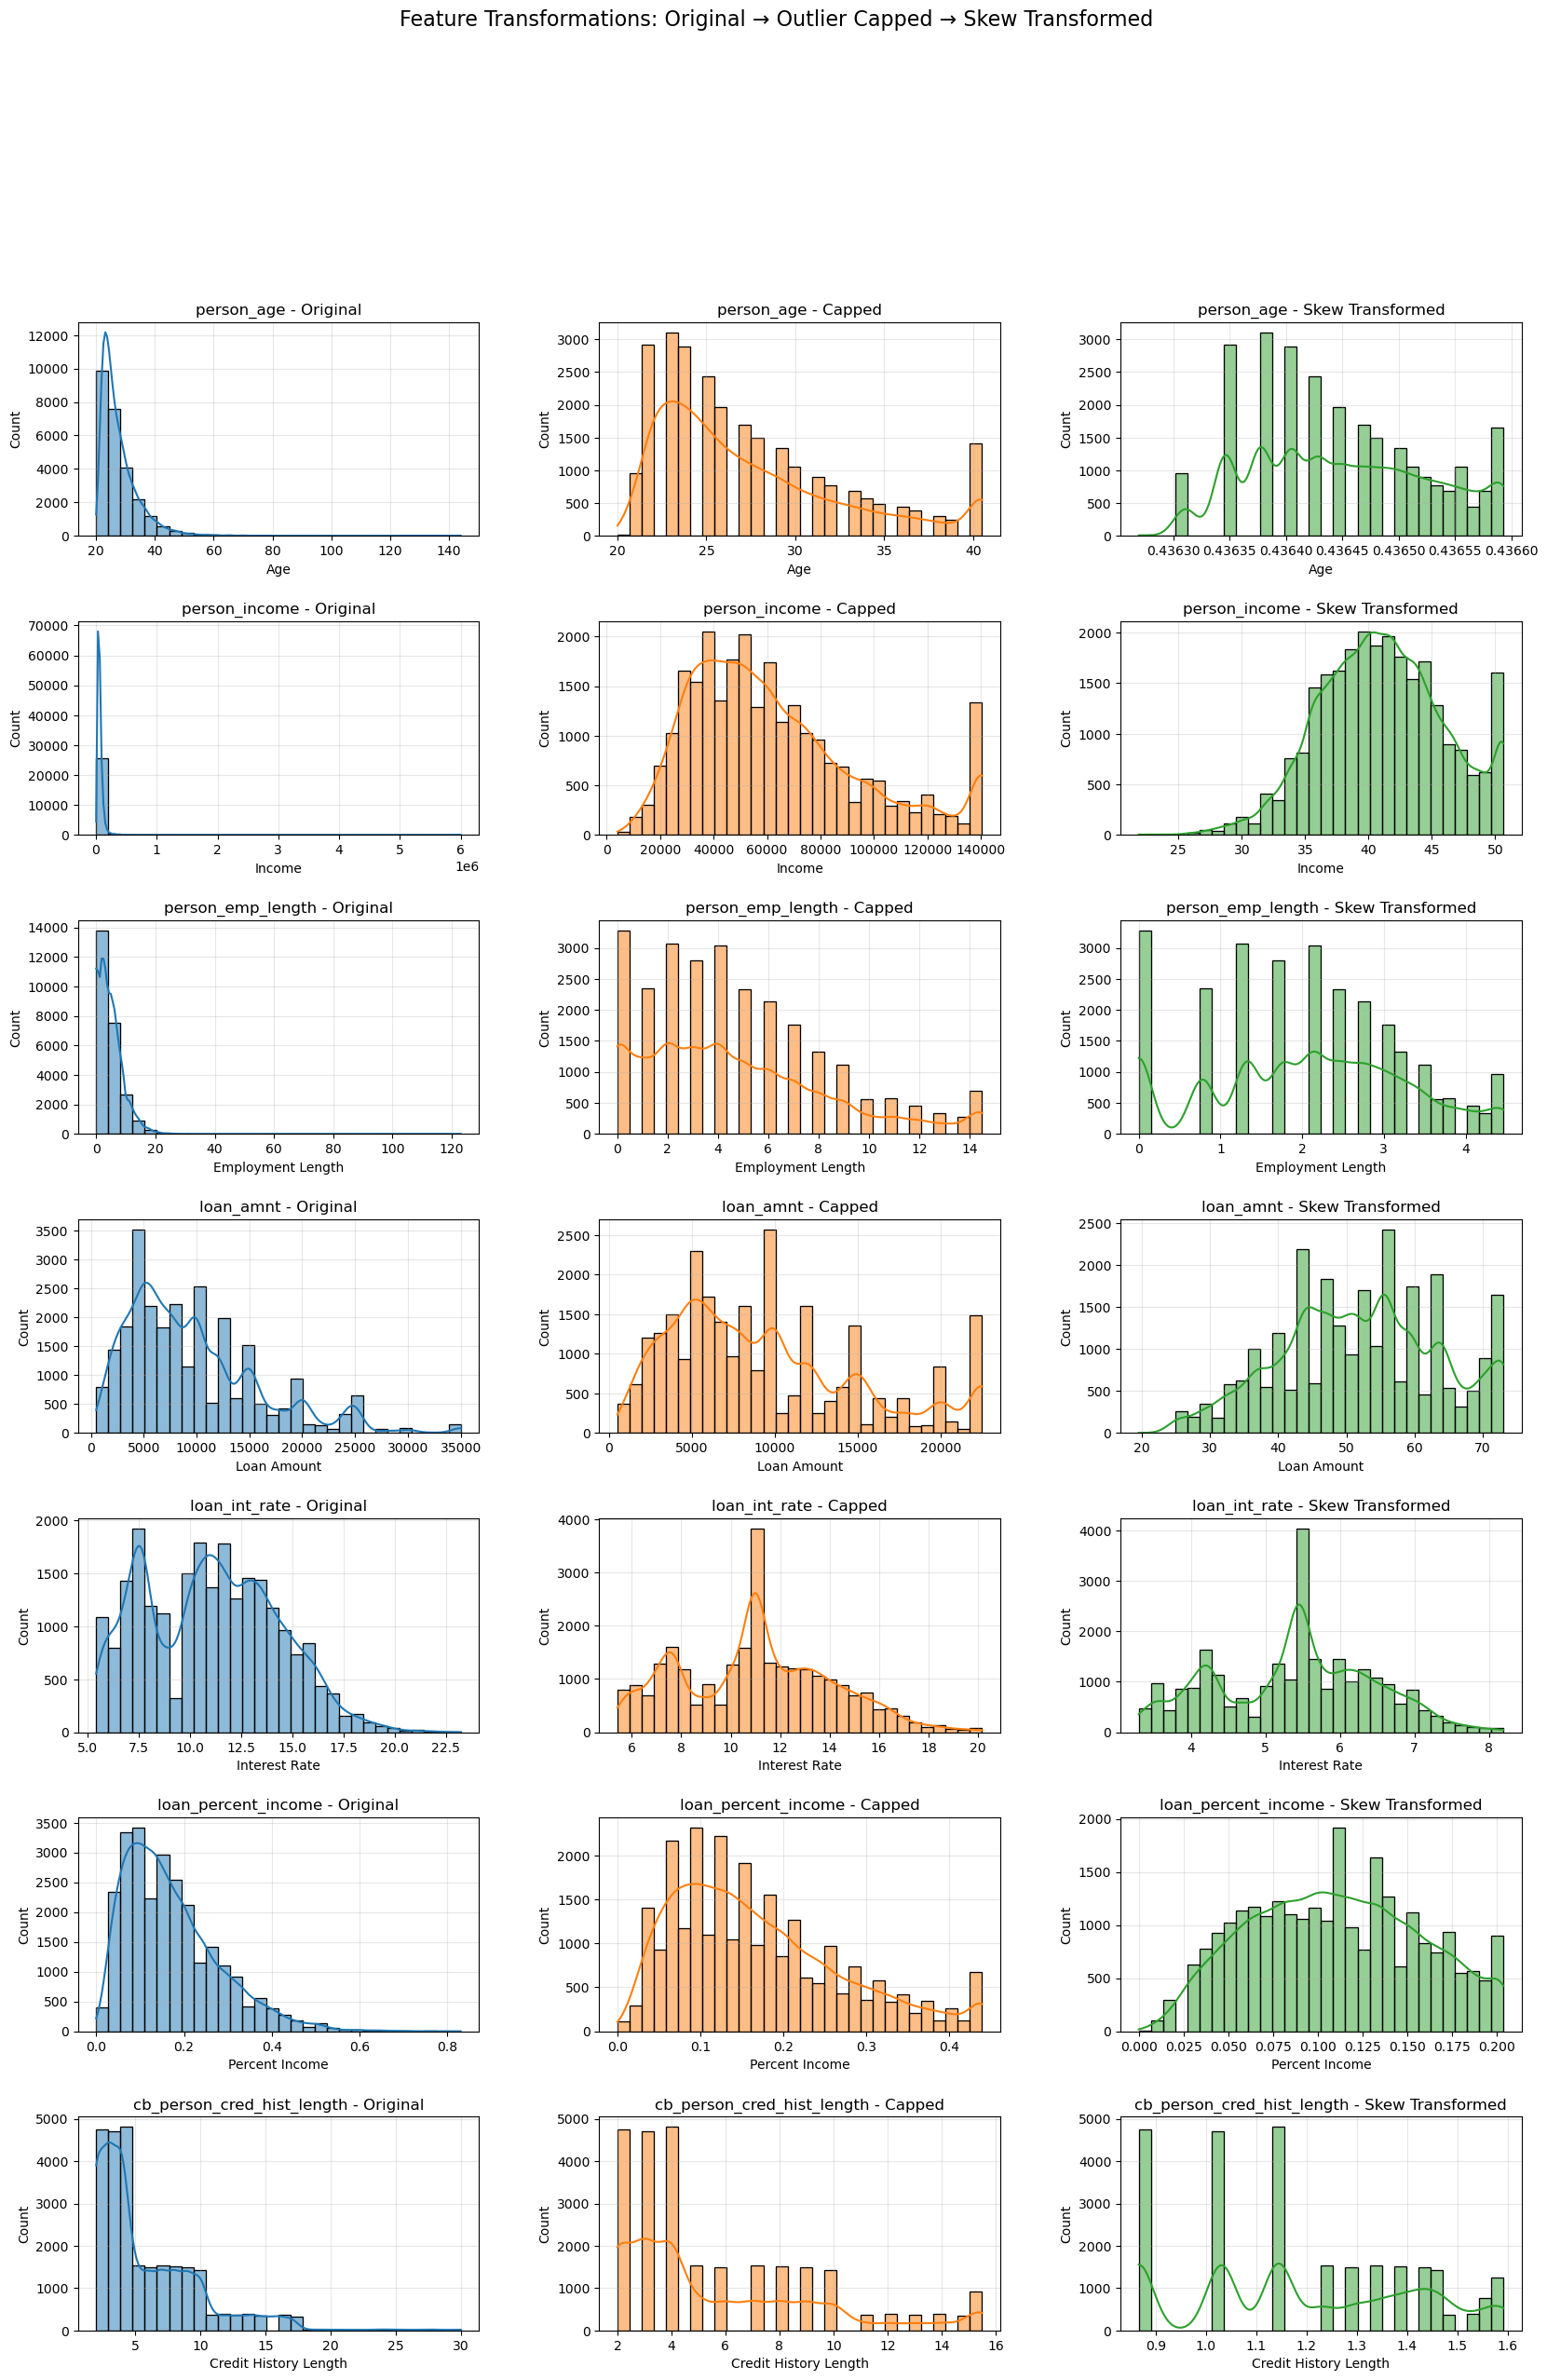

In [39]:
fig, axes = plt.subplots(7, 3, figsize=(20, 28))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Row 0: person_age
sns.histplot(X_train["person_age"].dropna(), bins=30, kde=True, color="C0", ax=axes[0, 0])
axes[0, 0].set_title("person_age - Original")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha=0.3)

sns.histplot(X_train_capped["person_age"].dropna(), bins=30, kde=True, color="C1", ax=axes[0, 1])
axes[0, 1].set_title("person_age - Capped")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha=0.3)

sns.histplot(X_train_log["person_age"].dropna(), bins=30, kde=True, color="C2", ax=axes[0, 2])
axes[0, 2].set_title("person_age - Skew Transformed")
axes[0, 2].set_xlabel("Age")
axes[0, 2].set_ylabel("Count")
axes[0, 2].grid(alpha=0.3)

# Row 1: person_income
sns.histplot(X_train["person_income"].dropna(), bins=30, kde=True, color="C0", ax=axes[1, 0])
axes[1, 0].set_title("person_income - Original")
axes[1, 0].set_xlabel("Income")
axes[1, 0].set_ylabel("Count")
axes[1, 0].grid(alpha=0.3)

sns.histplot(X_train_capped["person_income"].dropna(), bins=30, kde=True, color="C1", ax=axes[1, 1])
axes[1, 1].set_title("person_income - Capped")
axes[1, 1].set_xlabel("Income")
axes[1, 1].set_ylabel("Count")
axes[1, 1].grid(alpha=0.3)

sns.histplot(X_train_log["person_income"].dropna(), bins=30, kde=True, color="C2", ax=axes[1, 2])
axes[1, 2].set_title("person_income - Skew Transformed")
axes[1, 2].set_xlabel("Income")
axes[1, 2].set_ylabel("Count")
axes[1, 2].grid(alpha=0.3)

# Row 2: person_emp_length
sns.histplot(X_train["person_emp_length"].dropna(), bins=30, kde=True, color="C0", ax=axes[2, 0])
axes[2, 0].set_title("person_emp_length - Original")
axes[2, 0].set_xlabel("Employment Length")
axes[2, 0].set_ylabel("Count")
axes[2, 0].grid(alpha=0.3)

sns.histplot(X_train_capped["person_emp_length"].dropna(), bins=30, kde=True, color="C1", ax=axes[2, 1])
axes[2, 1].set_title("person_emp_length - Capped")
axes[2, 1].set_xlabel("Employment Length")
axes[2, 1].set_ylabel("Count")
axes[2, 1].grid(alpha=0.3)

sns.histplot(X_train_log["person_emp_length"].dropna(), bins=30, kde=True, color="C2", ax=axes[2, 2])
axes[2, 2].set_title("person_emp_length - Skew Transformed")
axes[2, 2].set_xlabel("Employment Length")
axes[2, 2].set_ylabel("Count")
axes[2, 2].grid(alpha=0.3)

# Row 3: loan_amnt
sns.histplot(X_train["loan_amnt"].dropna(), bins=30, kde=True, color="C0", ax=axes[3, 0])
axes[3, 0].set_title("loan_amnt - Original")
axes[3, 0].set_xlabel("Loan Amount")
axes[3, 0].set_ylabel("Count")
axes[3, 0].grid(alpha=0.3)

sns.histplot(X_train_capped["loan_amnt"].dropna(), bins=30, kde=True, color="C1", ax=axes[3, 1])
axes[3, 1].set_title("loan_amnt - Capped")
axes[3, 1].set_xlabel("Loan Amount")
axes[3, 1].set_ylabel("Count")
axes[3, 1].grid(alpha=0.3)

sns.histplot(X_train_log["loan_amnt"].dropna(), bins=30, kde=True, color="C2", ax=axes[3, 2])
axes[3, 2].set_title("loan_amnt - Skew Transformed")
axes[3, 2].set_xlabel("Loan Amount")
axes[3, 2].set_ylabel("Count")
axes[3, 2].grid(alpha=0.3)

# Row 4: loan_int_rate
sns.histplot(X_train["loan_int_rate"].dropna(), bins=30, kde=True, color="C0", ax=axes[4, 0])
axes[4, 0].set_title("loan_int_rate - Original")
axes[4, 0].set_xlabel("Interest Rate")
axes[4, 0].set_ylabel("Count")
axes[4, 0].grid(alpha=0.3)

sns.histplot(X_train_capped["loan_int_rate"].dropna(), bins=30, kde=True, color="C1", ax=axes[4, 1])
axes[4, 1].set_title("loan_int_rate - Capped")
axes[4, 1].set_xlabel("Interest Rate")
axes[4, 1].set_ylabel("Count")
axes[4, 1].grid(alpha=0.3)

sns.histplot(X_train_log["loan_int_rate"].dropna(), bins=30, kde=True, color="C2", ax=axes[4, 2])
axes[4, 2].set_title("loan_int_rate - Skew Transformed")
axes[4, 2].set_xlabel("Interest Rate")
axes[4, 2].set_ylabel("Count")
axes[4, 2].grid(alpha=0.3)

# Row 5: loan_percent_income
sns.histplot(X_train["loan_percent_income"].dropna(), bins=30, kde=True, color="C0", ax=axes[5, 0])
axes[5, 0].set_title("loan_percent_income - Original")
axes[5, 0].set_xlabel("Percent Income")
axes[5, 0].set_ylabel("Count")
axes[5, 0].grid(alpha=0.3)

sns.histplot(X_train_capped["loan_percent_income"].dropna(), bins=30, kde=True, color="C1", ax=axes[5, 1])
axes[5, 1].set_title("loan_percent_income - Capped")
axes[5, 1].set_xlabel("Percent Income")
axes[5, 1].set_ylabel("Count")
axes[5, 1].grid(alpha=0.3)

sns.histplot(X_train_log["loan_percent_income"].dropna(), bins=30, kde=True, color="C2", ax=axes[5, 2])
axes[5, 2].set_title("loan_percent_income - Skew Transformed")
axes[5, 2].set_xlabel("Percent Income")
axes[5, 2].set_ylabel("Count")
axes[5, 2].grid(alpha=0.3)

# Row 6: cb_person_cred_hist_length
sns.histplot(X_train["cb_person_cred_hist_length"].dropna(), bins=30, kde=True, color="C0", ax=axes[6, 0])
axes[6, 0].set_title("cb_person_cred_hist_length - Original")
axes[6, 0].set_xlabel("Credit History Length")
axes[6, 0].set_ylabel("Count")
axes[6, 0].grid(alpha=0.3)

sns.histplot(X_train_capped["cb_person_cred_hist_length"].dropna(), bins=30, kde=True, color="C1", ax=axes[6, 1])
axes[6, 1].set_title("cb_person_cred_hist_length - Capped")
axes[6, 1].set_xlabel("Credit History Length")
axes[6, 1].set_ylabel("Count")
axes[6, 1].grid(alpha=0.3)

sns.histplot(X_train_log["cb_person_cred_hist_length"].dropna(), bins=30, kde=True, color="C2", ax=axes[6, 2])
axes[6, 2].set_title("cb_person_cred_hist_length - Skew Transformed")
axes[6, 2].set_xlabel("Credit History Length")
axes[6, 2].set_ylabel("Count")
axes[6, 2].grid(alpha=0.3)

plt.suptitle("Feature Transformations: Original → Outlier Capped → Skew Transformed", fontsize=16, y=1.0)
plt.show()